In [1]:
# %%
# Importação das bibliotecas necessárias
# Manipulação de dados
import os
import glob
import ctypes
import site
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import pywt  # Biblioteca para transformacoes wavelet
import keras_tuner as kt
# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

import keras

from keras import backend as K


# Componentes do modelo Seq2Seq com Atenção
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense, Concatenate, TimeDistributed, Attention
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    LayerNormalization,
    Flatten,
    Reshape,
    SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Otimizar alocacao de memoria GPU - reduz fragmentacao
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'  # Reduce TensorFlow logging verbosity

# Garante runtime de GPU no Arch Linux (cuSOLVER e libs CUDA via wheel)
def configure_tensorflow_gpu_runtime():
    """Configura paths CUDA do venv e pre-carrega bibliotecas antes do import do TensorFlow."""
    current_ld = os.environ.get('LD_LIBRARY_PATH', '')
    candidate_dirs = []

    for sp in site.getsitepackages():
        candidate_dirs.extend(glob.glob(os.path.join(sp, 'nvidia', '*', 'lib')))

    if 'VIRTUAL_ENV' in os.environ:
        candidate_dirs.extend(
            glob.glob(
                os.path.join(
                    os.environ['VIRTUAL_ENV'],
                    'lib',
                    'python*',
                    'site-packages',
                    'nvidia',
                    '*',
                    'lib',
                )
            )
        )

    valid_dirs = []
    for lib_dir in candidate_dirs:
        if os.path.isdir(lib_dir) and lib_dir not in valid_dirs:
            valid_dirs.append(lib_dir)

    if valid_dirs:
        merged = ':'.join(valid_dirs)
        os.environ['LD_LIBRARY_PATH'] = f"{merged}:{current_ld}" if current_ld else merged

        # Pre-carrega libs CUDA para evitar falha de resolucao dinamica no kernel do VS Code
        preload_libs = [
            'libcudart.so.12',
            'libcublas.so.12',
            'libcudnn.so.9',
            'libcusolver.so.11',
        ]
        for lib_name in preload_libs:
            for lib_dir in valid_dirs:
                lib_path = os.path.join(lib_dir, lib_name)
                if os.path.exists(lib_path):
                    try:
                        ctypes.CDLL(lib_path, mode=ctypes.RTLD_GLOBAL)
                    except OSError:
                        pass
                    break

    return valid_dirs

cuda_lib_dirs = configure_tensorflow_gpu_runtime()
print('CUDA lib dirs found:', len(cuda_lib_dirs))
from tcn import TCN

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('Python:', os.environ.get('VIRTUAL_ENV', 'sem VIRTUAL_ENV'))
print('GPUs:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1788016649.185946  222765 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


CUDA lib dirs found: 11
TensorFlow: 2.21.0
Python: /home/zino/projects/wind-speed-forescasting/.venv
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sys
from pathlib import Path
from tensorflow.keras.utils import plot_model

import matplotlib.dates as mdates
import pandas as pd
import keras_tuner as kt

project_root = Path.cwd().resolve()
if not (project_root / "data" / "dataset.csv").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.s2s_lstm_bi_wrapper import S2SLSTMBidirectionalWrapper
from src.models.s2s_lstm_wrapper import S2SLSTMWrapper
from src.models.s2s_tcn_bi_wrapper import S2STCNBidirectionalWrapper
from src.models.s2s_tcn_wrapper import S2STCNWrapper
from src.models.s2s_transformer_preln_wrapper import S2STransformerPrelnWrapper
from src.utils import wavelet_denoising

models = [S2SLSTMBidirectionalWrapper(), S2SLSTMWrapper(), S2STCNBidirectionalWrapper(), S2STCNWrapper(), S2STransformerPrelnWrapper()]

dataset = pd.read_csv(project_root / "data" / "dataset.csv")
dataset["id"] = pd.to_datetime(dataset["id"], format="mixed")
dataset = dataset.sort_values("id").set_index("id")

train_ratio = 0.75
val_ratio = 0.20

train_end = int(len(dataset) * train_ratio)
val_end = train_end + int(len(dataset) * val_ratio)

train_df = dataset.iloc[:train_end].copy()
val_df = dataset.iloc[train_end:val_end].copy()
test_df = dataset.iloc[val_end:].copy()

input_steps = 72
output_steps = 36
model_data = {}
for model_base in models:
    wrapper = model_base.prepare(
        train_df,
        val_df,
        input_steps=input_steps,
        output_steps=output_steps,
        target_col="ws100_wavelet",
        denoise=["ws100"],
    )
    hp = kt.HyperParameters()
    model = wrapper.build(hp)
    plot_model(wrapper.model, to_file=f'model_structure_{model_base.__class__.__name__}.png', show_trainable=True, show_shapes=True, show_layer_names=True, expand_nested=True, dpi=300)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(f'../models/{model_base.__class__.__name__}_best_model.h5.keras', monitor='val_loss', save_best_only=True)
    ]
    history = wrapper.fit(epochs=100, batch_size=32, verbose=1, callbacks=callbacks, use_validation=True)
    model_data[model_base.__class__.__name__] = {
        "wrapper": wrapper,
        "history": history
    }
print("Rows:", len(dataset))
print("Train/val/test:", len(train_df), len(val_df), len(test_df))
print("Final training loss:", history.history["loss"][-1])

I0000 00:00:1788016652.003969  222765 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1788016652.005114  222765 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3875 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1788016656.577099  566003 cuda_dnn.cc:461] Loaded cuDNN version 92000


174/174 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0628 - mae: 0.1154 - val_loss: 0.0042 - val_mae: 0.0489 - learning_rate: 0.0064
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0037 - mae: 0.0452 - val_loss: 0.0022 - val_mae: 0.0361 - learning_rate: 0.0064
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0019 - mae: 0.0317 - val_loss: 7.1783e-04 - val_mae: 0.0201 - learning_rate: 0.0064
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 8.6552e-04 - mae: 0.0216 - val_loss: 4.1481e-04 - val_mae: 0.0155 - learning_rate: 0.0064
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.9145e-04 - mae: 0.0176 - val_loss: 4.6519e-04 - val_mae: 0.0179 - learning_rate: 0.0064
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.6359e-04 - mae: 0.0157 - val_loss: 4.1007e-04 - val_mae: 0.0168 - learning_rate: 0.0064
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3.8130e-04 - mae: 0.0142 - val_loss: 1.6301e-04 - val_mae:

I0000 00:00:1788016928.310083  566004 service.cc:153] XLA service 0x7ffacc01d250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788016928.310115  566004 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1660, Compute Capability 7.5 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1788016928.533713  566004 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788016930.370079  566004 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140082__.170


...

169/174 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4336 - mae: 0.4336

I0000 00:00:1788017184.219942  566003 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_269318__.240
I0000 00:00:1788017193.833274  839951 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_add_reduce_subtract_fusion', 964 bytes spill stores, 960 bytes spill loads

I0000 00:00:1788017205.949884  566003 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_add_reduce_subtract_fusion', 856 bytes spill stores, 852 bytes spill loads



174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.4271 - mae: 0.4271

I0000 00:00:1788017207.192752  566006 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_271800__.42
I0000 00:00:1788017209.704118  565994 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_271800__.42


174/174 ━━━━━━━━━━━━━━━━━━━━ 60s 191ms/step - loss: 0.2086 - mae: 0.2086 - val_loss: 0.0714 - val_mae: 0.0714 - learning_rate: 0.0010
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0641 - mae: 0.0641 - val_loss: 0.0271 - val_mae: 0.0271 - learning_rate: 0.0010
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0452 - mae: 0.0452 - val_loss: 0.0437 - val_mae: 0.0437 - learning_rate: 0.0010
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0391 - mae: 0.0391 - val_loss: 0.0231 - val_mae: 0.0231 - learning_rate: 0.0010
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0356 - mae: 0.0356 - val_loss: 0.0191 - val_mae: 0.0191 - learning_rate: 0.0010
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0322 - mae: 0.0322 - val_loss: 0.0237 - val_mae: 0.0237 - learning_rate: 0.0010
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0293 - mae: 0.0293 - val_loss: 0.0197 - val_mae: 0.0197 - learning_rate: 0.0010
Ep

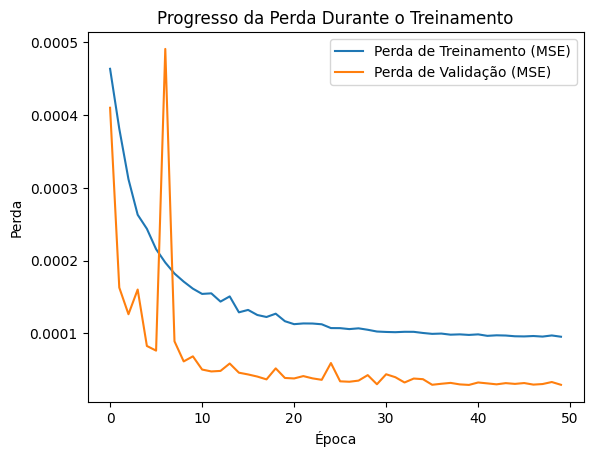

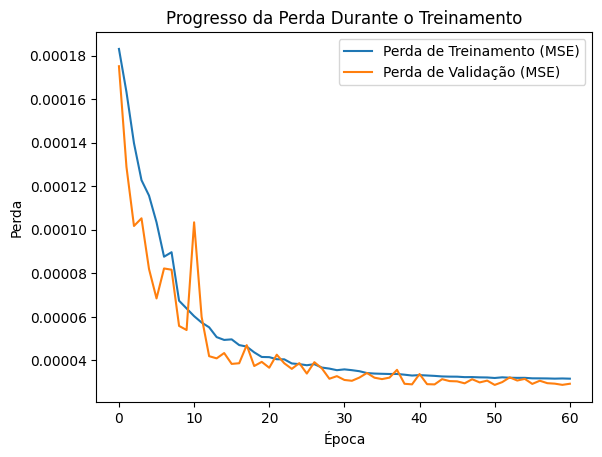

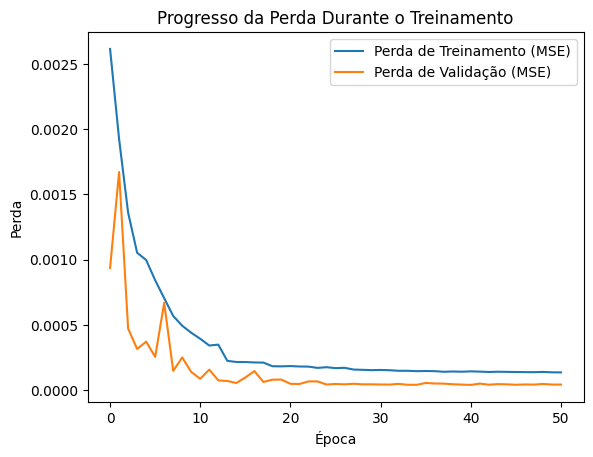

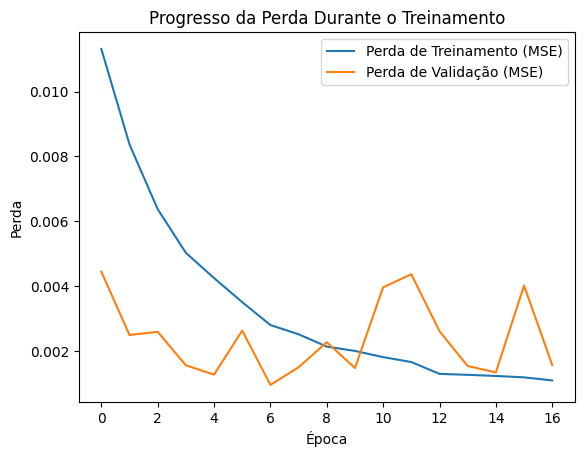

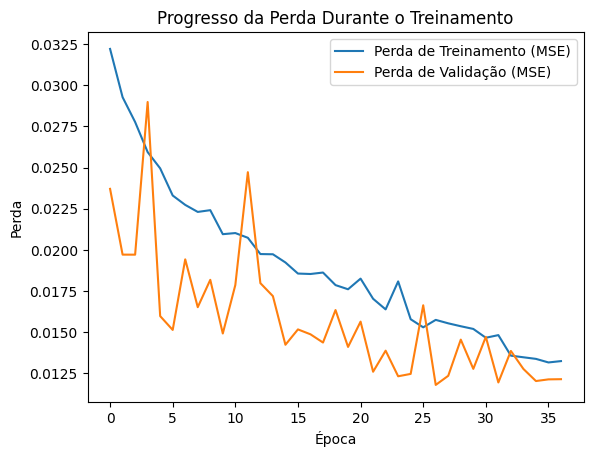

In [3]:
for model_name, data in model_data.items():
    history = data["history"]
    plt.plot(history.history['loss'][5:], label='Perda de Treinamento (MSE)')
    plt.plot(history.history['val_loss'][5:], label='Perda de Validação (MSE)') #pula o primeiro pois a tcn tem perda alta na primeira época
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend()
    plt.title('Progresso da Perda Durante o Treinamento')
    plt.savefig(f'../images/training_loss_{model_name}.png', dpi=300)
    plt.show()

In [4]:
forecast_df = dataset.copy()

predictions_dict = {}
for model_name, data in model_data.items():
    wrapper = data["wrapper"]
    
    predictions, actuals = wrapper.rolling_forecast(forecast_df, test_start=val_end)
    predictions_dict[model_name] = {
        "predictions": predictions,
        "actuals": actuals
    }

Starting rolling forecast from index 7182 to 7526
Starting rolling forecast from index 7182 to 7526
Starting rolling forecast from index 7182 to 7526
Starting rolling forecast from index 7182 to 7526
Starting rolling forecast from index 7182 to 7526


I0000 00:00:1788017401.834364  566005 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_404787__.37


In [5]:

for model_name, data in predictions_dict.items():
    predictions = data["predictions"]
    actuals = data["actuals"]

    forecast_index = forecast_df.index[val_end + output_steps : val_end + output_steps - 1 + len(actuals)]
    predictions = predictions.reshape(-1)[1:]
    actuals = actuals.reshape(-1)

                            expected  predicted_S2SLSTMBidirectionalWrapper  \
id                                                                            
2021-11-06 05:29:59.999997  6.976737                               7.059842   
2021-11-06 05:40:00.000001  6.912985                               6.992902   
2021-11-06 05:49:59.999996  6.870333                               6.931883   
2021-11-06 06:00:00.000000  6.812312                               6.889963   
2021-11-06 06:10:00.000004  6.659720                               6.833553   

                            predicted_S2SLSTMWrapper  \
id                                                     
2021-11-06 05:29:59.999997                  7.063446   
2021-11-06 05:40:00.000001                  6.992471   
2021-11-06 05:49:59.999996                  6.931162   
2021-11-06 06:00:00.000000                  6.889569   
2021-11-06 06:10:00.000004                  6.834018   

                            predicted_S2STCNBidirecti

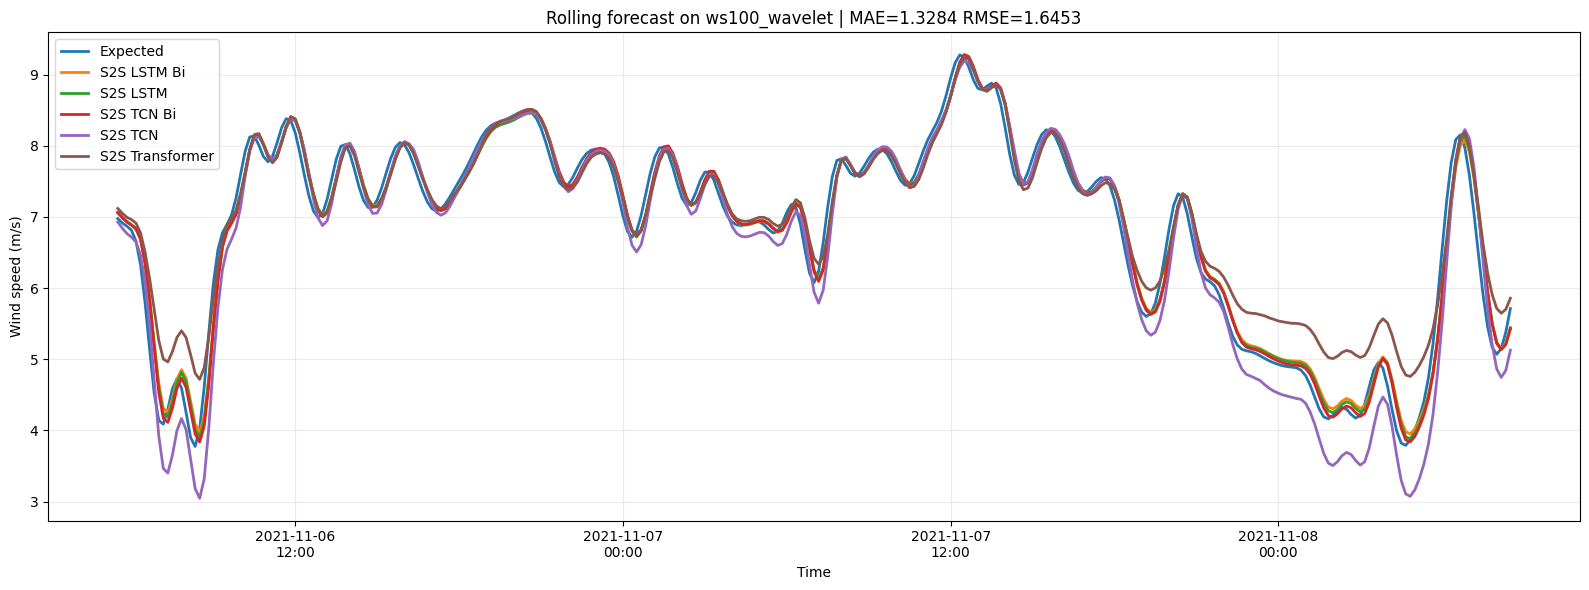

In [27]:
#print(f"Predictions shape: {predictions.shape}")
#old_predictions_df = pd.read_csv(project_root / "data" / "old_prediction.csv")
#old_predictions = old_predictions_df['predictions'].values
#old_predictions = old_predictions.reshape(-1)
#print(f"Old predictions shape: {old_predictions_df.shape}")
#print(old_predictions_df.head())
#print(predictions.head())


mae = mean_absolute_error(actuals[:-1], predictions)
rmse = np.sqrt(mean_squared_error(actuals[:-1], predictions))

results_dict = {
    "expected": actuals[1:-36],
}
for model_name, data in predictions_dict.items():
    results_dict[f"predicted_{model_name}"] = data["predictions"].reshape(-1)[36:-1]
results = pd.DataFrame(
    results_dict,
    index=forecast_index[:-36],
)
pretty_name = {
    "expected": "Expected",
    "predicted_S2SLSTMBidirectionalWrapper": "S2S LSTM Bi",
    "predicted_S2SLSTMWrapper": "S2S LSTM",
    "predicted_S2STCNBidirectionalWrapper": "S2S TCN Bi",
    "predicted_S2STCNWrapper": "S2S TCN",
    "predicted_S2STransformerPrelnWrapper": "S2S Transformer",
}
print(results.head())

fig, ax = plt.subplots(figsize=(16, 6))
for result in results_dict:
    ax.plot(forecast_index[:-36], results[result], label=pretty_name.get(result, result), linewidth=2)
ax.set_title(f"Rolling forecast on ws100_wavelet | MAE={mae:.4f} RMSE={rmse:.4f}")
ax.set_xlabel("Time")
ax.set_ylabel("Wind speed (m/s)")
ax.grid(alpha=0.25)
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()

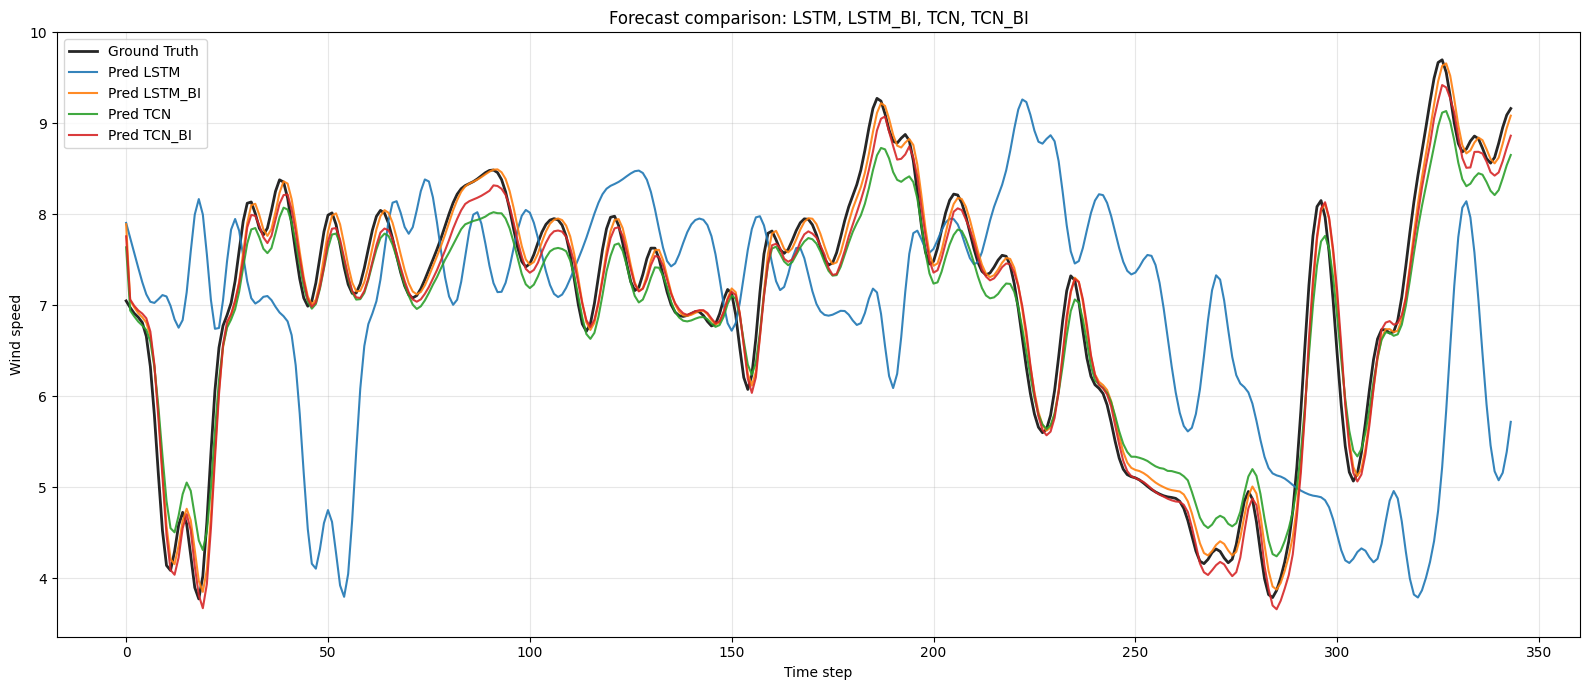

In [7]:
# Added: load predictions from all models and plot in one combined chart
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / "data" / "results").exists():
    project_root = project_root.parent

model_files = {
    "LSTM": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM" / "predictions.csv",
    "LSTM_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM_Bidirectional" / "predictions.csv",
    "TCN": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN" / "predictions.csv",
    "TCN_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN_Bidirectional" / "predictions.csv",
}

results = {}
for model_name, file_path in model_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing predictions file for {model_name}: {file_path}")
    df = pd.read_csv(file_path)
    if "prediction" not in df.columns or "actual" not in df.columns:
        raise ValueError(f"{file_path} must contain columns: prediction, actual")
    results[model_name] = df[["actual", "prediction"]].reset_index(drop=True)

min_len = min(len(df) for df in results.values())
for model_name in results:
    results[model_name] = results[model_name].iloc[:min_len]

actual = results["LSTM"]["actual"].to_numpy()

plt.figure(figsize=(16, 7))
plt.plot(actual, label="Ground Truth", color="black", linewidth=2, alpha=0.85)
for model_name, df in results.items():
    plt.plot(df["prediction"].to_numpy(), label=f"Pred {model_name}", alpha=0.9)

plt.title("Forecast comparison: LSTM, LSTM_BI, TCN, TCN_BI")
plt.xlabel("Time step")
plt.ylabel("Wind speed")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
# Análise detalhada: métricas de erro e de tempo por modelo
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_dirs = {
    "LSTM": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM",
    "LSTM_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM_Bidirectional",
    "TCN": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN",
    "TCN_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN_Bidirectional",
}


def compute_detailed_metrics(actual, prediction):
    error = actual - prediction
    abs_error = np.abs(error)
    mape = np.mean(abs_error / np.maximum(np.abs(actual), 1e-8)) * 100
    return {
        "MAE": mean_absolute_error(actual, prediction),
        "MSE": mean_squared_error(actual, prediction),
        "RMSE": np.sqrt(mean_squared_error(actual, prediction)),
        "MAPE (%)": mape,
        "R²": r2_score(actual, prediction),
        "Max Error": np.max(abs_error),
        "Bias (média do erro)": np.mean(error),
        "Std do Erro": np.std(error),
        "P90 |Erro|": np.percentile(abs_error, 90),
        "P95 |Erro|": np.percentile(abs_error, 95),
        "P99 |Erro|": np.percentile(abs_error, 99),
        "Correlação": np.corrcoef(actual, prediction)[0, 1],
    }


detailed_metrics = {}
predictions_data = {}
for model_name, model_dir in model_dirs.items():
    df = pd.read_csv(model_dir / "predictions.csv")
    with (model_dir / "metrics.json").open(encoding="utf-8") as handle:
        meta = json.load(handle)
    actual = df["actual"].to_numpy()
    prediction = df["prediction"].to_numpy()
    stats = compute_detailed_metrics(actual, prediction)
    stats["test_samples"] = meta["test_samples"]
    stats["train_epochs"] = meta["train_epochs"]
    stats["prediction_time_sec"] = meta["prediction_time_sec"]
    stats["per_sample_time_ms"] = meta["prediction_time_sec"] / meta["test_samples"] * 1000
    detailed_metrics[model_name] = stats
    predictions_data[model_name] = {"actual": actual, "prediction": prediction}

error_columns = [
    "MAE", "MSE", "RMSE", "MAPE (%)", "R²", "Max Error",
    "Bias (média do erro)", "Std do Erro", "P90 |Erro|", "P95 |Erro|", "P99 |Erro|", "Correlação",
]
time_columns = ["prediction_time_sec", "per_sample_time_ms", "test_samples", "train_epochs"]

print("=== Estatísticas de erro por modelo ===")
print(pd.DataFrame(detailed_metrics).T[error_columns].to_string(float_format=lambda v: f"{v:,.4f}"))
print()
print("=== Estatísticas de tempo por modelo ===")
print(pd.DataFrame(detailed_metrics).T[time_columns].to_string(float_format=lambda v: f"{v:,.4f}"))


=== Estatísticas de erro por modelo ===
           MAE    MSE   RMSE  MAPE (%)      R²  Max Error  Bias (média do erro)  Std do Erro  P90 |Erro|  P95 |Erro|  P99 |Erro|  Correlação
LSTM    1.4536 3.3685 1.8354   22.5566 -0.7422     5.0865                0.0970       1.8328      3.1131      3.6229      4.8839      0.0632
LSTM_BI 0.1703 0.0495 0.2225    2.6376  0.9744     0.8426               -0.0076       0.2223      0.3409      0.4414      0.6885      0.9872
TCN     0.2829 0.1144 0.3382    4.2801  0.9408     0.8234                0.1135       0.3186      0.5090      0.6333      0.7535      0.9877
TCN_BI  0.1927 0.0620 0.2489    2.8809  0.9679     0.8273                0.0836       0.2345      0.3902      0.4735      0.7037      0.9858

=== Estatísticas de tempo por modelo ===
         prediction_time_sec  per_sample_time_ms  test_samples  train_epochs
LSTM                 20.5081             59.6166      344.0000      100.0000
LSTM_BI              20.0038             58.1506      344.0

In [9]:
# Parâmetros da busca Optuna: carrega best_trial.json da otimização para cada modelo
import json as _json

optuna_dirs = {
    "LSTM": project_root / "data" / "results" / "optuna" / "Seq2Seq_LSTM",
    "LSTM_BI": project_root / "data" / "results" / "optuna" / "Seq2Seq_LSTM_Bidirectional",
    "TCN": project_root / "data" / "results" / "optuna" / "Seq2Seq_TCN",
    "TCN_BI": project_root / "data" / "results" / "optuna" / "Seq2Seq_TCN_Bidirectional",
}

optuna_params = {}
for model_name, optuna_dir in optuna_dirs.items():
    path = optuna_dir / "best_trial.json"
    if not path.exists():
        raise FileNotFoundError(f"Missing Optuna result for {model_name}: {path}")
    with path.open(encoding="utf-8") as handle:
        result = _json.load(handle)
    optuna_params[model_name] = {
        "best_value": result["best_value"],
        "n_trials": result["n_trials"],
        "seed": result["seed"],
        "best_params": result["best_params"],
    }

print("=== Optuna run params por modelo ===")
for model_name, info in optuna_params.items():
    print(f"\n{model_name}: best_val={info['best_value']:.6f} (trials={info['n_trials']}, seed={info['seed']})")
    for param, value in info["best_params"].items():
        print(f"  {param} = {value}")


=== Optuna run params por modelo ===

LSTM: best_val=0.000017 (trials=100, seed=42)
  learning_rate = 0.0074545283317214136
  lstm_units = 64
  encoder_dropout_rate = 0.05
  decoder_dropout_rate = 0.0

LSTM_BI: best_val=0.000020 (trials=100, seed=42)
  learning_rate = 0.006403023029268099
  lstm_units = 64
  encoder_dropout_rate = 0.05
  decoder_dropout_rate = 0.15000000000000002

TCN: best_val=0.000044 (trials=100, seed=42)
  learning_rate = 0.009778662493093181
  encoder_filters = 32
  encoder_kernel_size = 2
  encoder_nb_stacks = 2
  encoder_dropout_rate = 0.4
  encoder_dilation_rate = 1
  decoder_filters = 64
  decoder_kernel_size = 2
  decoder_nb_stacks = 1
  decoder_dropout_rate = 0.0
  decoder_dilation_rate = 1

TCN_BI: best_val=0.000050 (trials=100, seed=42)
  learning_rate = 0.003969484893321028
  encoder_filters = 64
  encoder_kernel_size = 2
  encoder_nb_stacks = 1
  encoder_dropout_rate = 0.2
  encoder_dilation_rate = 2
  decoder_filters = 80
  decoder_kernel_size = 2
  dec

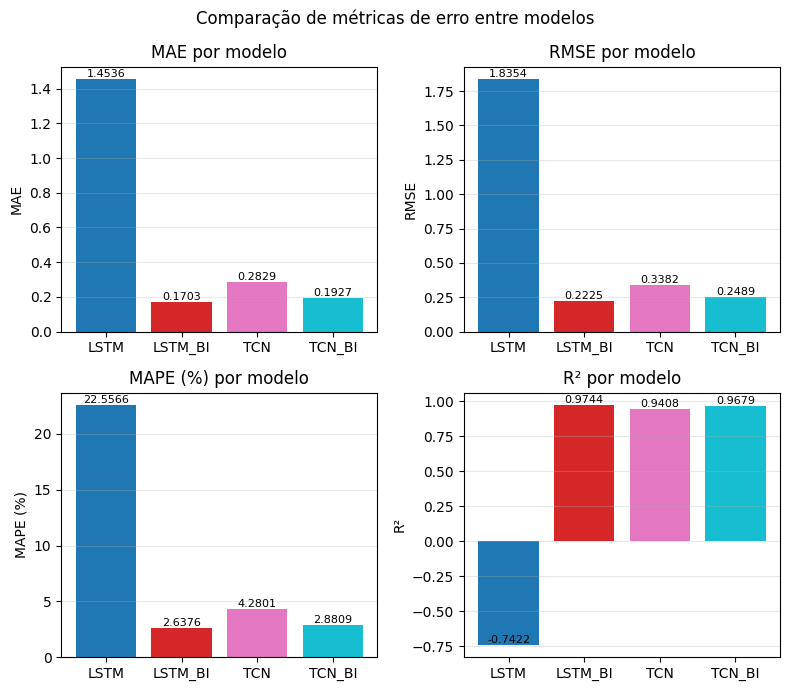

/tmp/ipykernel_222765/2485154101.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)
/tmp/ipykernel_222765/2485154101.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)
/tmp/ipykernel_222765/2485154101.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)
/tmp/ipykernel_222765/2485154101.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotl

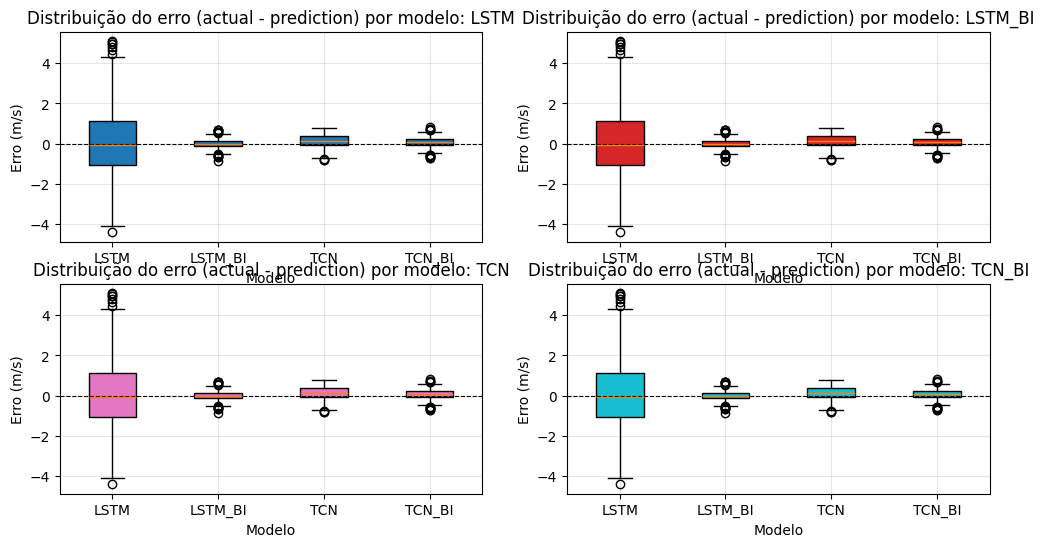

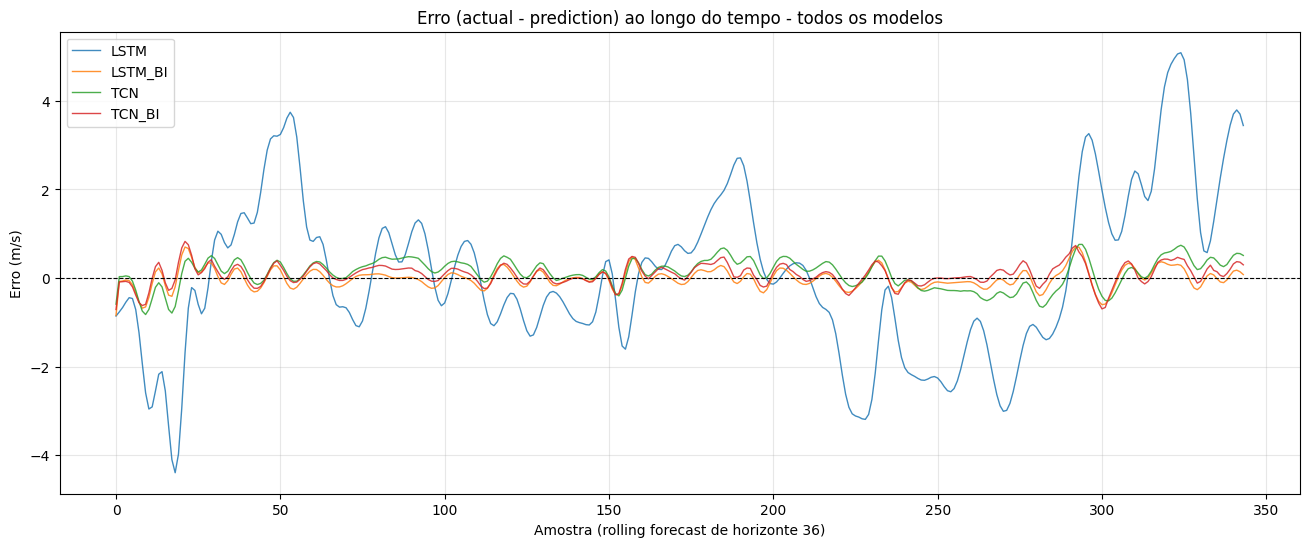

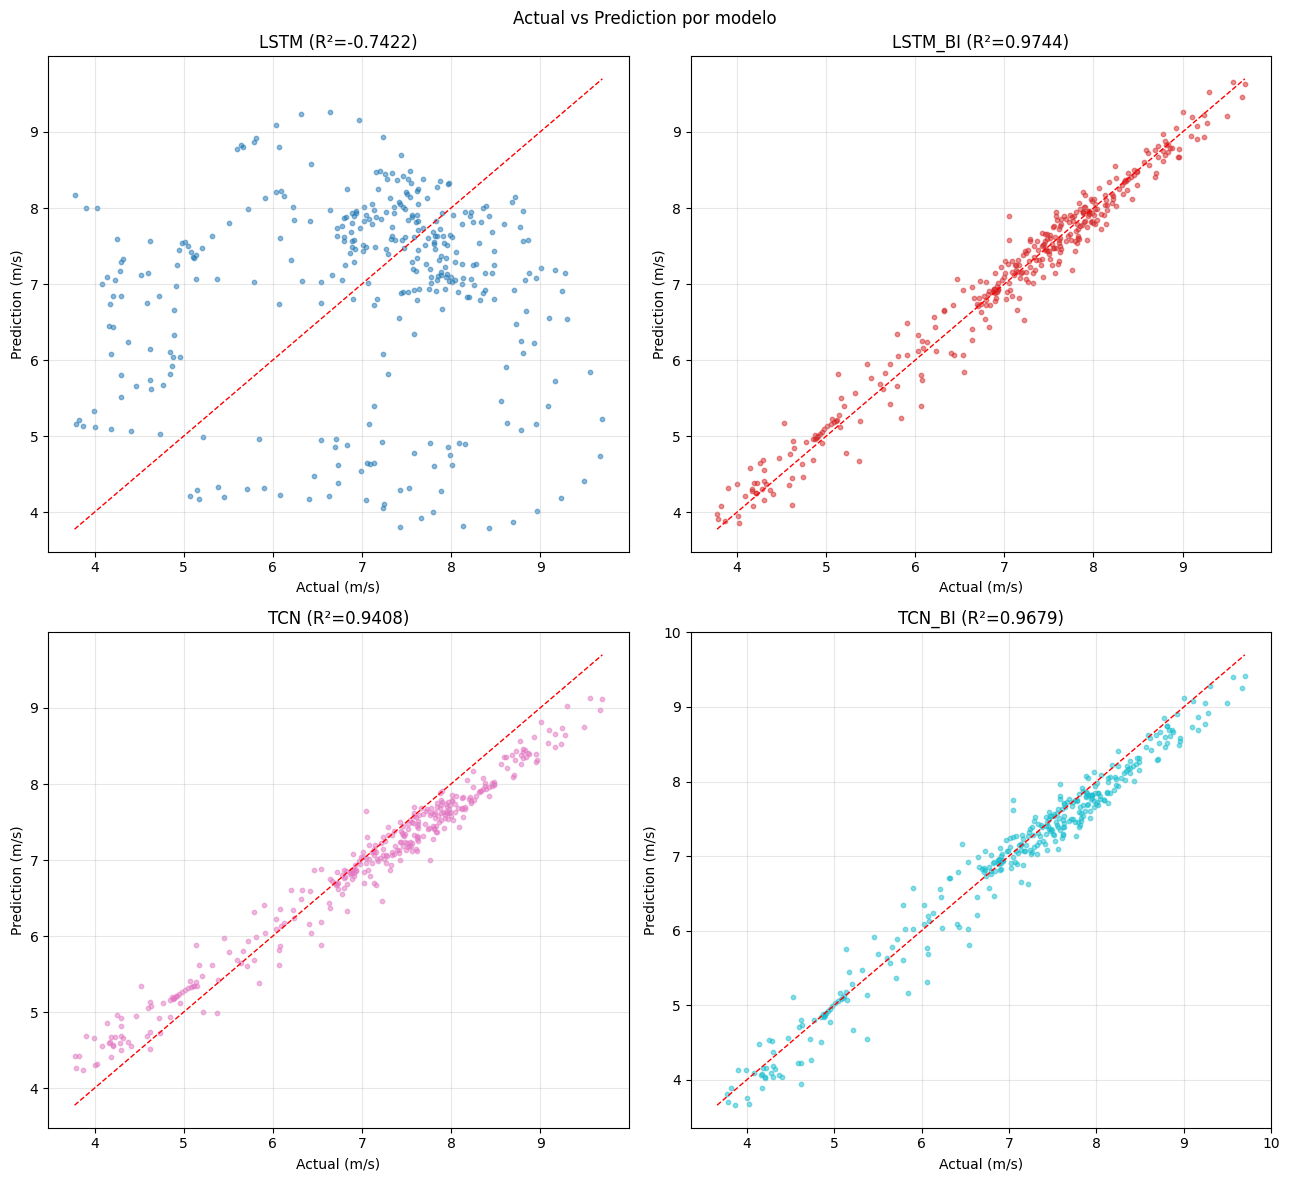

In [10]:
# Plot agregado: métricas de erro (todos os modelos na mesma figura)
model_names = list(model_dirs.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(model_names)))
model_colors = dict(zip(model_names, colors))

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for ax, metric in zip(axes.flatten(), ["MAE", "RMSE", "MAPE (%)", "R²"]):
    values = [detailed_metrics[m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=[model_colors[m] for m in model_names])
    ax.set_title(f"{metric} por modelo")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3, axis="y")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Comparação de métricas de erro entre modelos")
plt.tight_layout()
plt.show()

# Distribuição do erro (boxplot) - todos os modelos na mesma figura
fig, axes = plt.subplots(2,2, figsize=(12, 6))
errors_by_model = [predictions_data[m]["actual"] - predictions_data[m]["prediction"] for m in model_names]
for ax, model_name in zip(axes.flatten(), model_names):
    bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(model_colors[model_name])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Distribuição do erro (actual - prediction) por modelo: {model_name}")
    ax.set_ylabel("Erro (m/s)")
    ax.set_xlabel("Modelo")
    ax.grid(alpha=0.3)
plt.show()

# Erro ao longo do tempo - todos os modelos na mesma figura
fig, ax = plt.subplots( figsize=(16, 6))
for model_name in model_names:
    error = predictions_data[model_name]["actual"] - predictions_data[model_name]["prediction"]
    ax.plot(error, label=model_name, linewidth=1, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Erro (actual - prediction) ao longo do tempo - todos os modelos")
ax.set_xlabel("Amostra (rolling forecast de horizonte 36)")
ax.set_ylabel("Erro (m/s)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# Scatter actual vs prediction - um subplot por modelo em uma única figura agregada
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, model_name in zip(axes.flatten(), model_names):
    d = predictions_data[model_name]
    ax.scatter(d["actual"], d["prediction"], s=10, alpha=0.5, color=model_colors[model_name])
    lo = min(d["actual"].min(), d["prediction"].min())
    hi = max(d["actual"].max(), d["prediction"].max())
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_title(f"{model_name} (R²={detailed_metrics[model_name]['R²']:.4f})")
    ax.set_xlabel("Actual (m/s)")
    ax.set_ylabel("Prediction (m/s)")
    ax.grid(alpha=0.3)
plt.suptitle("Actual vs Prediction por modelo")
plt.tight_layout()
plt.show()


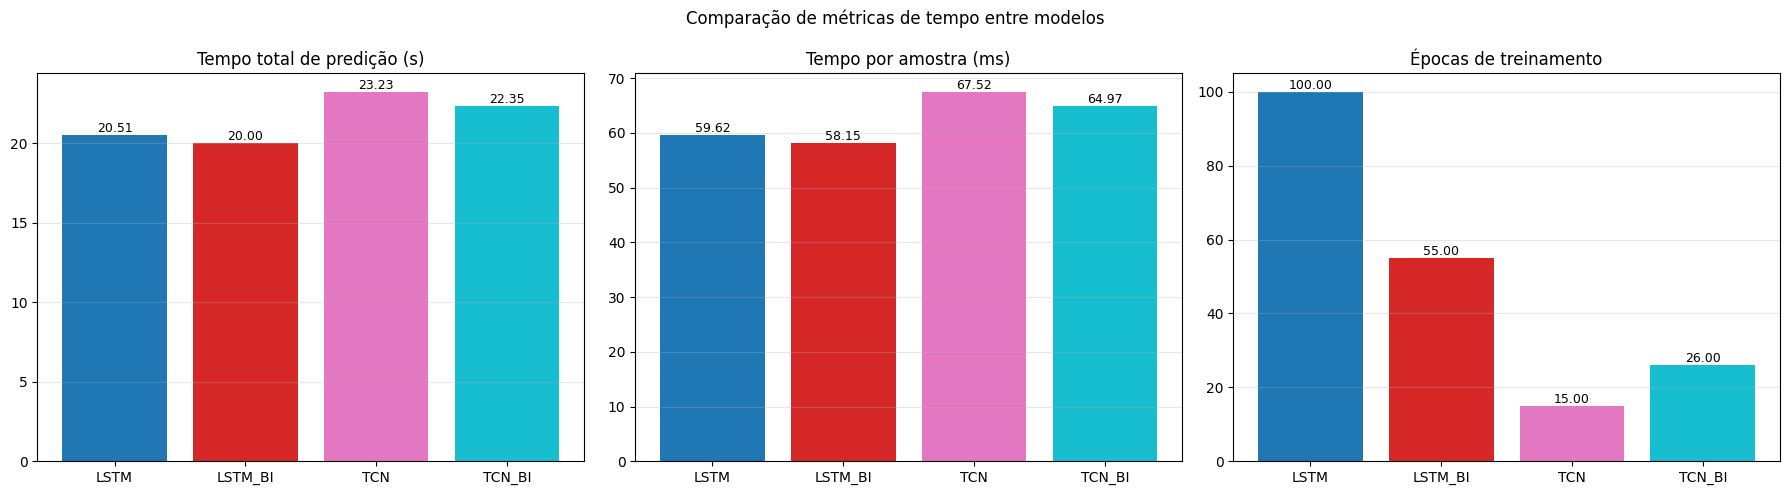

In [11]:
# Plot agregado: métricas de tempo (todos os modelos na mesma figura)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
time_metrics = [
    ("prediction_time_sec", "Tempo total de predição (s)"),
    ("per_sample_time_ms", "Tempo por amostra (ms)"),
    ("train_epochs", "Épocas de treinamento"),
]
for ax, (metric, title) in zip(axes, time_metrics):
    values = [detailed_metrics[m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=[model_colors[m] for m in model_names])
    ax.set_title(title)
    ax.grid(alpha=0.3, axis="y")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Comparação de métricas de tempo entre modelos")
plt.tight_layout()
plt.show()
